# 1. Definicion y Adquisicion de Datos

Nuestro modelo se basa en utilizar ML como **gemelo digital** del proceso de pasteurizacion y un Algoritmo Genetico como motor de busqueda de consignas operativas. Antes de entrenar la Red Neuronal predictiva es necesario definir que variables debe representar el sistema SCADA/IIoT para aproximar de forma realista el comportamiento termohidraulico de la planta.

Basandonos en los trabajos de Tarapata et al. (2025), relacionados con la prediccion y monitorizacion del fouling, Yang et al. (2023), sobre la combinacion de redes neuronales y algoritmos geneticos, y en la logica fisica de un intercambiador de calor de placas, se genera un dataset sintetico de planta que reproduce una operacion de pasteurizacion bajo control dinamico.

La version actual del simulador representa una planta operando en condiciones seguras. La temperatura de salida de la leche se mantiene aproximadamente constante alrededor del umbral de pasteurizacion mediante una logica **PID/supervisor de seguridad**, mientras que la variabilidad del proceso se refleja principalmente en la temperatura de entrada, el caudal, la temperatura de servicio requerida, el consumo energetico, la caida de presion y la evolucion del fouling.

## 1.1 Definicion del Dataset (inputs y targets)

Necesitamos generar un CSV o tabla SQL con datos historicos/sinteticos que representen una planta de pasteurizacion operando de forma realista. En esta version, la planta trabaja alrededor de un caudal nominal de **5000 L/h**, incorporando pequenas oscilaciones operativas propias de un entorno industrial. La temperatura de servicio no se obtiene mediante una tabla operaria discreta, sino mediante una logica **PID/supervisor** que calcula la consigna necesaria para mantener la temperatura de salida de la leche en condiciones compatibles con la pasteurizacion.

El objetivo del dataset no es generar combinaciones artificiales no factibles, sino reproducir datos de planta seguros: los registros productivos deben mantener `T_out_leche >= 72.3 C`, incorporando al mismo tiempo variabilidad de lote, ruido de sensores, ruido de control, evolucion estocastica del fouling, penalizacion por maldistribucion termica y eficiencia variable de bomba.

### Variables de entrada (Features/*X*)

Son los datos que alimentaran a la red neuronal para representar el estado del sistema. Estas variables pueden modificarse o ampliarse en el futuro para mejorar el rendimiento del gemelo digital y del optimizador, por lo que no deben considerarse absolutas.

| Variable | Descripcion Tecnica | Justificacion | Unidad Sugerida |
| :--- | :--- | :--- | :--- |
| **$T_{in\_leche}$** | Temperatura real de entrada de la leche cruda. | Variable de perturbacion principal. Presenta variabilidad estacional y condiciona la energia necesaria para alcanzar la temperatura de pasteurizacion. | C |
| **$F_{flow}$** | Caudal volumetrico de leche. | Afecta a la transferencia termica, al arrastre mecanico del fouling y al consumo de bombeo. En el dataset de planta oscila alrededor del caudal nominal de 5000 L/h. | L/h |
| **$T_{servicio}$** | Temperatura del fluido caloportador a la entrada del intercambiador. | Variable de control calculada por la logica PID/supervisor para compensar temperatura de entrada, caudal, propiedades del lote y fouling acumulado. | C |
| **$t_{ciclo}$** | Tiempo transcurrido desde la ultima limpieza CIP. | Variable critica para representar la evolucion temporal del fouling y la degradacion progresiva del intercambiador. | min |
| **$\Delta P$** | Caida de presion en el intercambiador. | Indicador hidraulico asociado a la obstruccion progresiva por ensuciamiento. | bar |
| **$Is\_Cleaning$** | Flag de limpieza quimica CIP. | Permite identificar los periodos de limpieza y los reinicios del estado de ensuciamiento. Estos registros se excluyen posteriormente del dataset productivo. | 0/1 |

### Variables objetivo (Targets/$Y$)

Las variables objetivo son las salidas que el gemelo digital debe predecir para que el Algoritmo Genetico pueda evaluar cada escenario de operacion.

| Variable | Descripcion Tecnica | Objetivo en el Modelo |
| :--- | :--- | :--- |
| **$E_{consumo}$** | Consumo energetico total instantaneo, expresado en kW. Incluye el consumo termico asociado a la caldera o vapor y el consumo electrico de bombeo. | **KPI principal.** El modelo debe aprender a predecirlo para que el optimizador pueda minimizar el consumo energetico especifico. |
| **$T_{out\_leche}$** | Temperatura de salida de la leche tras el intercambio termico. | **Restriccion de seguridad alimentaria.** El modelo debe estimarla para verificar que la operacion mantiene $T_{out\_leche} \ge 72.3^\circ C$. En los datos de planta simulados esta variable permanece aproximadamente regulada por el PID/supervisor. |

### 1.2 Mitigacion del Sim2Real Gap: Inyeccion de Estocasticidad Fisica

Para evitar que la red neuronal aprenda una abstraccion matematica idealizada (overfitting a ecuaciones diferenciales perfectas), el simulador incorpora factores estocasticos que emulan el comportamiento de una planta SCADA real, pero mantiene una logica de operacion segura basada en control PID/supervisor. El objetivo no es generar combinaciones artificiales no factibles, sino reproducir datos de planta en condiciones normales de produccion, donde el sistema de control corrige la temperatura de servicio para garantizar la pasteurizacion.

1. **Variabilidad por Lotes (Composicion de la Leche):** al contrario que el agua, la leche presenta variaciones en sus niveles de grasa y proteina segun el origen o la estacionalidad. Para modelarlo, las propiedades termofisicas (calor especifico $C_p$ y densidad $\rho$) dejan de ser constantes. Tras cada ciclo de limpieza (CIP), cuando ingresa un nuevo lote de producto, estos valores se extraen de una distribucion Gaussiana.
2. **Control PID/Supervisor de Temperatura:** la temperatura de servicio se calcula mediante una consigna base corregida por la temperatura de entrada de la leche, el fouling acumulado y un margen de seguridad. Si el balance termico predice una salida inferior a $72.3^\circ C$, el supervisor eleva la consigna de servicio hasta recuperar la condicion de seguridad.
3. **Fouling Dinamico y Estocastico:** la aglomeracion de proteinas y minerales en las placas del intercambiador no es perfectamente homogenea. Se aplica un factor de ruido del $\pm5\%$ sobre la cinetica de deposicion ($k_{dep}$), simulando la formacion irregular de depositos.
4. **Incertidumbre de Instrumentacion:** se mantiene ruido sobre variables como presion, consumo energetico y temperatura. No obstante, al tratarse de datos de planta en produccion, la temperatura de salida registrada se limita a valores compatibles con la restriccion de seguridad alimentaria.

Con este enfoque, el dataset conserva variabilidad realista sin perder el comportamiento industrial que queremos modelar: una planta segura, con ruido de sensores y variabilidad fisica, pero sin registros de produccion por debajo del umbral de pasteurizacion.

### 1.3.3. Logica de Control: PID/Supervisor de Seguridad

En esta version, el simulador vuelve a representar una logica de control dinamica, mas cercana a una planta real de pasteurizacion. La temperatura de servicio no se obtiene desde una tabla discreta, sino mediante una consigna tipo PID/supervisor que compensa tres efectos principales:

1. **Temperatura de entrada de la leche:** si la leche entra mas fria, el sistema incrementa la temperatura de servicio.
2. **Ensuciamiento acumulado:** a medida que aumenta $R_f(t)$, disminuye la transferencia termica y el controlador compensa elevando $T_{servicio}$.
3. **Variabilidad de proceso:** se anade ruido de control para reproducir pequenas oscilaciones propias de una instalacion industrial.

La consigna inicial se calcula mediante una ley de control simplificada:

$$T_{servicio}^{PID} = T_{base} + K_{Tin}(T_{ref} - T_{in}) + K_f R_f(t) + \eta_{PID}$$

donde $\eta_{PID}$ representa ruido de control. Posteriormente, se aplica un supervisor de seguridad: si el balance termico predice una temperatura de salida inferior al umbral de pasteurizacion, se calcula la temperatura minima de servicio necesaria para cumplir $T_{out} \ge 72.3^\circ C$ y se recalcula el balance termico.

Este enfoque garantiza que el dataset represente datos de planta en regimen de produccion: todos los registros productivos cumplen la restriccion termica, pero mantienen variabilidad fisica, ruido instrumental, ensuciamiento dinamico, penalizacion por maldistribucion y eficiencia variable de bomba.

In [7]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [8]:
# _Fijamos una semilla para reproducibilidad
np.random.seed(1)

In [9]:
# ==========================================
# CONFIGURACION DE LA SIMULACION (V3.4 - PID/SUPERVISOR DE SEGURIDAD)
# Basado en Manika(2004), Deka&Datta(2017) y Tarapata(2025)
# Mantiene ruido, propiedades por lote, fouling no lineal,
# maldistribucion termica y eficiencia variable de bomba.
# ==========================================

NUM_DIAS = 180
FREQ_MUESTREO = 5
TOTAL_REGISTROS = int((NUM_DIAS * 24 * 60) / FREQ_MUESTREO)

# Parametros fisicos del intercambiador
U_CLEAN = 3500.0
AREA = 15.0

# Propiedades nominales de la leche
CP_DISENO = 3890.0
RHO_DISENO = 1030.0

# Seguridad alimentaria
T_OUT_OBJETIVO = 72.3
MARGEN_CONTROL = 0.30         # margen interno para absorber ruido/control
T_OUT_CONTROL = T_OUT_OBJETIVO + MARGEN_CONTROL

# Operacion de planta
FLOW_OPERACION_L_H = 5000.0
FLOW_STD_L_H = 400.0
FLOW_MIN_L_H = 3500.0
FLOW_MAX_L_H = 5500.0

# Limites fisicos del servicio
T_SERVICIO_MIN = 76.0
T_SERVICIO_MAX = 95.0

# Parametros hidraulicos y energeticos
K_HIDRAULICA = 2e-8
ETA_CALDERA = 0.90
ETA_BOMBA_MAX = 0.78
K_CURVA_BOMBA = 2.5e-7
FLOW_BEP_L_H = 4800.0
FLOW_DISENO_TERMICO_L_H = 4500.0
FLOW_REF_EFICIENCIA_L_H = 5150.0

# Perdidas fijas independientes del caudal (ambiente, tubo de retencion,
# consumo base de auxiliares): penalizan el caudal bajo en consumo especifico,
# de forma que el minimo de E_consumo/F_flow quede anclado en FLOW_REF_EFICIENCIA_L_H
# en vez de premiar bajar el caudal por debajo del nivel historico de planta.
P_FIXED_KW = 15.0

# Fouling
R_FOULING_INICIAL = 0.00001
R_FOULING_MAX_OPERATIVO = 0.0008


def calcular_effectiveness(flujo_l_h, rho, cp, fouling_factor):
    """
    Calcula la efectividad termica usando epsilon-NTU.
    Incluye penalizacion por maldistribucion/canalizacion cuando
    el caudal supera el caudal optimo termico de diseno.
    """
    flujo_kg_s = (flujo_l_h / 3600.0) * (rho / 1000.0)

    if flujo_l_h > FLOW_DISENO_TERMICO_L_H:
        factor_canalizacion = (FLOW_DISENO_TERMICO_L_H / flujo_l_h) ** 0.85
        u_efectivo = U_CLEAN * factor_canalizacion
    else:
        u_efectivo = U_CLEAN

    u_dirty = 1.0 / ((1.0 / u_efectivo) + fouling_factor)
    c_min = flujo_kg_s * cp
    ntu = (u_dirty * AREA) / c_min
    effectiveness = ntu / (1.0 + ntu)

    return effectiveness, c_min


def calcular_t_out_y_q(t_in_leche, t_servicio, flujo_l_h, rho, cp, fouling_factor):
    """
    Calcula temperatura de salida y calor transferido con el modelo fisico.
    """
    effectiveness, c_min = calcular_effectiveness(
        flujo_l_h=flujo_l_h,
        rho=rho,
        cp=cp,
        fouling_factor=fouling_factor,
    )

    q_transferido_w = effectiveness * c_min * (t_servicio - t_in_leche)
    t_out_leche = t_in_leche + (q_transferido_w / c_min)

    return t_out_leche, q_transferido_w, effectiveness, c_min


def calcular_t_servicio_minima(t_in_leche, flujo_l_h, rho, cp, fouling_factor, t_out_deseada):
    """
    Calcula la temperatura minima de servicio necesaria para alcanzar
    una temperatura de salida deseada bajo el estado fisico actual.
    """
    effectiveness, _ = calcular_effectiveness(
        flujo_l_h=flujo_l_h,
        rho=rho,
        cp=cp,
        fouling_factor=fouling_factor,
    )

    # Evita divisiones inestables en casos extremos.
    effectiveness = max(effectiveness, 1e-6)

    t_servicio_requerida = t_in_leche + ((t_out_deseada - t_in_leche) / effectiveness)
    return t_servicio_requerida


def calcular_t_servicio_pid(
    t_in_leche,
    flujo_l_h,
    rho,
    cp,
    fouling_factor,
):
    """
    Control operacional simplificado tipo PID abierto.

    No invierte el balance térmico para imponer T_out_leche.
    Genera T_servicio como acción de control aproximada, dependiente de:
    - fouling;
    - caudal;
    - temperatura de entrada;
    - ruido de actuación.

    Esto permite que existan casos factibles, marginales y no factibles.
    """

    T_SERVICIO_BASE = 79

    # Compensación principal por fouling, como en el simulador antiguo.
    compensacion_fouling = fouling_factor * 25000.0

    # Si aumenta el caudal, baja el tiempo de residencia térmica.
    # El controlador intenta compensarlo subiendo algo T_servicio.
    compensacion_flujo = 0.0010 * (flujo_l_h - FLOW_OPERACION_L_H)

    # Si la leche entra más fría, se requiere algo más de temperatura de servicio.
    compensacion_tin = 0.12 * (4.0 - t_in_leche)

    # Ruido de actuación/PID.
    ruido_pid = np.random.normal(0.0, 0.40)

    t_servicio = (
        T_SERVICIO_BASE
        + compensacion_fouling
        + compensacion_flujo
        + compensacion_tin
        + ruido_pid
    )

    return float(np.clip(t_servicio, T_SERVICIO_MIN, T_SERVICIO_MAX))


def generar_dataset_pasteurizacion_v3_4_pid():
    data = []

    fouling_factor = R_FOULING_INICIAL
    tiempo_desde_limpieza = 0

    cp_actual = CP_DISENO
    rho_actual = RHO_DISENO

    print(
        f"Generando {TOTAL_REGISTROS} registros "
        f"(V3.4: PID/supervisor, datos de planta seguros)..."
    )

    for i in range(TOTAL_REGISTROS):
        # ---------------------------------------------------------
        # 1. ENTRADAS DE PROCESO
        # ---------------------------------------------------------

        # Temperatura de entrada con estacionalidad y ruido de proceso.
        estacion = np.sin(2.0 * np.pi * i / TOTAL_REGISTROS)
        t_in_leche = 4.0 + (3.0 * estacion) + np.random.normal(0.0, 0.3)
        t_in_leche = float(np.clip(t_in_leche, 0.0, 10.0))

        # Caudal de planta: no es un DOE ni una exploracion artificial.
        # Representa variacion real alrededor de la operacion nominal. Se
        # muestrea por rechazo (en vez de recortar/clip) para no acumular un
        # pico artificial de densidad justo en los limites del rango.
        while True:
            flujo_l_h = float(np.random.normal(FLOW_OPERACION_L_H, FLOW_STD_L_H))
            if FLOW_MIN_L_H <= flujo_l_h <= FLOW_MAX_L_H:
                break

        # ---------------------------------------------------------
        # 2. LOGICA DE LIMPIEZA (CIP)
        # ---------------------------------------------------------

        necesita_limpieza = (
            tiempo_desde_limpieza > (9 * 60)
            or fouling_factor > R_FOULING_MAX_OPERATIVO
        )

        if necesita_limpieza:
            is_cleaning = 1
            fouling_factor = R_FOULING_INICIAL
            tiempo_desde_limpieza = 0

            # Nuevo lote tras limpieza.
            cp_actual = CP_DISENO + np.random.normal(0.0, 50.0)
            rho_actual = RHO_DISENO + np.random.normal(0.0, 10.0)
        else:
            is_cleaning = 0

        # ---------------------------------------------------------
        # 3. CONTROL PID/SUPERVISOR DE TEMPERATURA
        # ---------------------------------------------------------

        t_servicio = calcular_t_servicio_pid(
            t_in_leche=t_in_leche,
            flujo_l_h=flujo_l_h,
            rho=rho_actual,
            cp=cp_actual,
            fouling_factor=fouling_factor,
        )

        # Primer calculo fisico con la accion PID.
        t_out_leche, q_transferido_w, effectiveness, c_min = calcular_t_out_y_q(
            t_in_leche=t_in_leche,
            t_servicio=t_servicio,
            flujo_l_h=flujo_l_h,
            rho=rho_actual,
            cp=cp_actual,
            fouling_factor=fouling_factor,
        )


        # Guardia final de datos de planta:
        # Si aun asi un caso extremo no puede cumplir por saturacion, se asume
        # desviacion de valvula/recirculacion y no se registra por debajo del umbral.
        if t_out_leche < T_OUT_OBJETIVO:
            t_servicio_requerida = calcular_t_servicio_minima(
                t_in_leche=t_in_leche,
                flujo_l_h=flujo_l_h,
                rho=rho_actual,
                cp=cp_actual,
                fouling_factor=fouling_factor,
                t_out_deseada=T_OUT_CONTROL,
            )
            t_servicio = float(np.clip(t_servicio_requerida, T_SERVICIO_MIN, T_SERVICIO_MAX))
            t_out_leche, q_transferido_w, effectiveness, c_min = calcular_t_out_y_q(
                t_in_leche=t_in_leche,
                t_servicio=t_servicio,
                flujo_l_h=flujo_l_h,
                rho=rho_actual,
                cp=cp_actual,
                fouling_factor=fouling_factor,
            )

            is_underpasteurized = int(t_out_leche < T_OUT_OBJETIVO)

        # ---------------------------------------------------------
        # 4. MODELO DE FOULING
        # ---------------------------------------------------------

        if is_cleaning == 0:
            ruido_cinetico = np.random.normal(1.0, 0.05)

            tasa_deposicion = (
                3e-8
                * np.exp(0.04 * t_servicio)
                * ruido_cinetico
            )

            # Mitigacion por esfuerzo cortante.
            factor_arrastre = (flujo_l_h / FLOW_DISENO_TERMICO_L_H) ** 1.2
            tasa_neta = tasa_deposicion / factor_arrastre

            fouling_factor += tasa_neta
            tiempo_desde_limpieza += FREQ_MUESTREO

        # ---------------------------------------------------------
        # 5. HIDRAULICA Y POTENCIA
        # ---------------------------------------------------------

        factor_obstruccion = 1.0 + (fouling_factor * 5000.0)
        delta_p_bar = K_HIDRAULICA * (flujo_l_h ** 2) * factor_obstruccion
        delta_p_bar += np.random.normal(0.0, 0.02)

        # Evita valores negativos por ruido instrumental.
        delta_p_bar = max(delta_p_bar, 0.01)

        delta_p_pa = delta_p_bar * 100000.0
        flujo_m3_s = (flujo_l_h / 1000.0) / 3600.0

        # Eficiencia variable de bomba respecto al BEP.
        eta_bomba = ETA_BOMBA_MAX - (K_CURVA_BOMBA * (flujo_l_h - FLOW_BEP_L_H) ** 2)
        eta_bomba = max(0.30, eta_bomba)

        potencia_bomba_w = (flujo_m3_s * delta_p_pa) / eta_bomba

        # Penalizacion energetica por canalizacion/maldistribucion a alto caudal:
        # operar por encima del caudal de referencia de eficiencia no solo exige
        # mas T_servicio (ya modelado en calcular_effectiveness con referencia al
        # caudal de diseno termico), tambien empeora el rendimiento efectivo de
        # generacion/distribucion de calor.
        if flujo_l_h > FLOW_REF_EFICIENCIA_L_H:
            factor_canalizacion_energia = (FLOW_REF_EFICIENCIA_L_H / flujo_l_h) ** 0.85
        else:
            factor_canalizacion_energia = 1.0

        consumo_termico_w = q_transferido_w / (ETA_CALDERA * factor_canalizacion_energia)

        e_consumo_kw = (consumo_termico_w + potencia_bomba_w) / 1000.0
        # Perdidas fijas independientes del caudal: penalizan operar por debajo
        # del caudal nominal, ya que se reparten entre menos litros producidos.
        e_consumo_kw += P_FIXED_KW
        # Ruido de instrumentacion/perdidas no modeladas: se incrementa
        # respecto a la version anterior (0.5 -> 5.0 kW) para evitar que el
        # consumo quede casi perfectamente determinado por las features.
        e_consumo_kw += np.random.normal(0.0, 5.0)

        # ---------------------------------------------------------
        # 6. RUIDO DE INSTRUMENTACION EN TEMPERATURA
        # ---------------------------------------------------------
        # Medida instrumental: se añade ruido, pero no se fuerza a cumplir 72.3 ºC.
        # Esto permite que el modelo aprenda casos factibles y no factibles.
        t_out_medida = t_out_leche + np.random.normal(0.0, 0.05)
        t_out_medida = float(np.clip(t_out_medida, 40.0, 95.0))


        data.append([
            i * FREQ_MUESTREO,
            round(t_in_leche, 2),
            round(flujo_l_h, 2),
            round(t_servicio, 2),
            round(tiempo_desde_limpieza, 0),
            round(delta_p_bar, 3),
            round(e_consumo_kw, 2),
            round(t_out_medida, 2),
            int(is_cleaning),
        ])

    columns = [
        'Time_min',
        'T_in_leche',
        'F_flow',
        'T_servicio',
        't_ciclo',
        'Delta_P',
        'E_consumo',
        'T_out_leche',
        'Is_Cleaning',
    ]

    df = pd.DataFrame(data, columns=columns)
    return df


df_simulado = generar_dataset_pasteurizacion_v3_4_pid()

print("Dataset V3.4 generado con PID/supervisor y fisica validada.")
display(df_simulado.head())
display(df_simulado.describe().round(2))

print("Comprobando temperatura de pasteurizacion:")
print(df_simulado['T_out_leche'].describe().round(2))
print(f"Registros con T_out_leche < {T_OUT_OBJETIVO} C: {(df_simulado['T_out_leche'] < T_OUT_OBJETIVO).sum()}")

# Guardar
output_path = Path("../../data/raw/pasteurizacion_dataset_simulado.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

df_simulado.to_csv(output_path, index=False)

Generando 51840 registros (V3.4: PID/supervisor, datos de planta seguros)...
Dataset V3.4 generado con PID/supervisor y fisica validada.


,Time_min,T_in_leche,F_flow,T_servicio,t_ciclo,Delta_P,E_consumo,T_out_leche,Is_Cleaning
0,0,4.49,4755.30,80.04,5,0.494,404.12,72.69,0
1,5,3.77,5127.62,81.24,10,0.515,449.92,72.58,0
2,10,4.34,4560.04,79.54,15,0.442,402.91,72.54,0
3,15,4.34,5360.64,81.93,20,0.598,482.67,72.55,0
4,20,3.92,5212.14,81.54,25,0.566,458.09,72.57,0


,Time_min,T_in_leche,F_flow,T_servicio,t_ciclo,Delta_P,E_consumo,T_out_leche,Is_Cleaning
count,51840.00,51840.00,51840.00,51840.00,51840.00,51840.00,51840.00,51840.00,51840.00
mean,129597.50,4.00,4917.89,81.54,272.39,0.60,435.17,72.60,0.01
std,74825.32,2.14,333.20,1.18,158.79,0.10,36.33,0.08,0.09
min,0.00,0.00,3520.84,77.80,0.00,0.26,295.88,72.18,0.00
25%,64798.75,1.89,4696.55,80.68,135.00,0.53,410.24,72.56,0.00
50%,129597.50,4.00,4942.76,81.53,270.00,0.60,433.64,72.60,0.00
75%,194396.25,6.10,5174.57,82.37,410.00,0.67,459.10,72.63,0.00
max,259195.00,7.98,5500.00,85.17,545.00,0.91,554.02,73.91,1.00


Comprobando temperatura de pasteurizacion:
count    51840.00
mean        72.60
std          0.08
min         72.18
25%         72.56
50%         72.60
75%         72.63
max         73.91
Name: T_out_leche, dtype: float64
Registros con T_out_leche < 72.3 C: 220


## 1.4 Visualizacion de datos

En esta seccion se grafican las variables generadas frente al tiempo para comprobar que el dataset tiene una dinamica coherente antes de pasar al EDA. La visualizacion permite verificar:

- La estacionalidad y variabilidad de `T_in_leche`.
- La respuesta dinamica de `T_servicio` calculada por la logica PID/supervisor.
- La variabilidad realista de `F_flow` alrededor del caudal nominal de planta.
- La evolucion de `t_ciclo`, `Delta_P` y `E_consumo` a lo largo de los ciclos de fouling y limpieza.
- La restriccion de seguridad sobre `T_out_leche`, que debe mantenerse por encima de 72.3 C en todos los registros productivos.

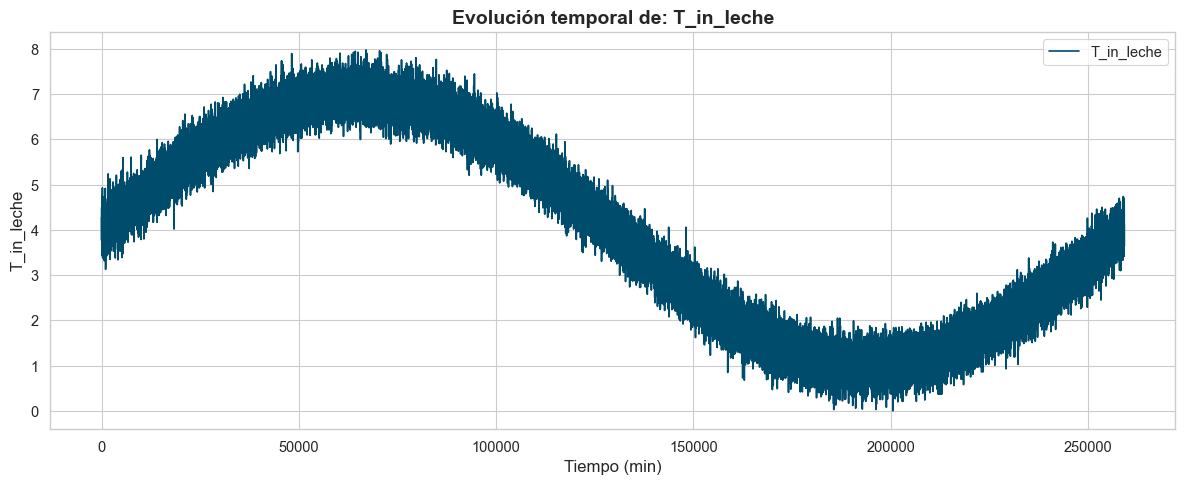

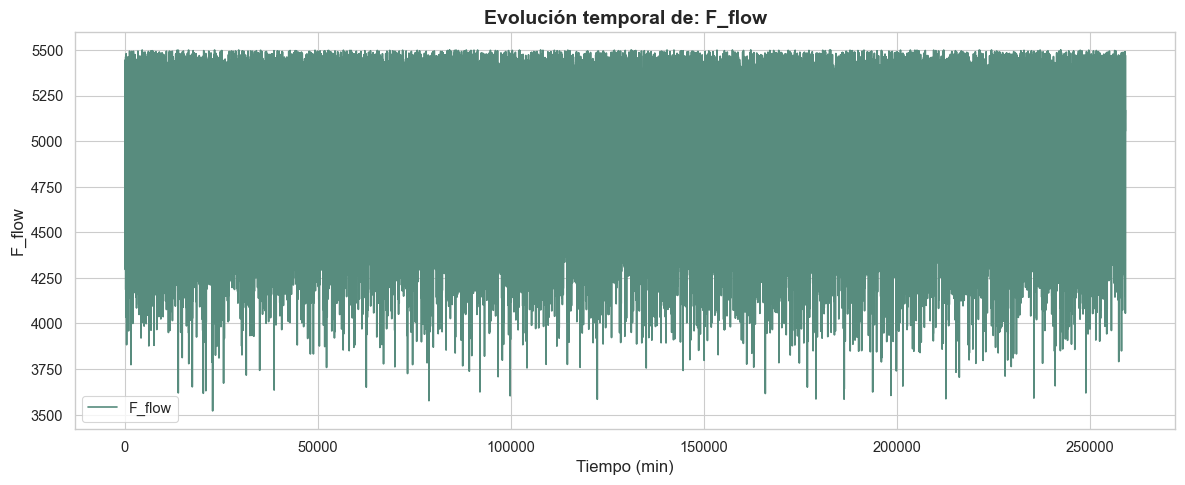

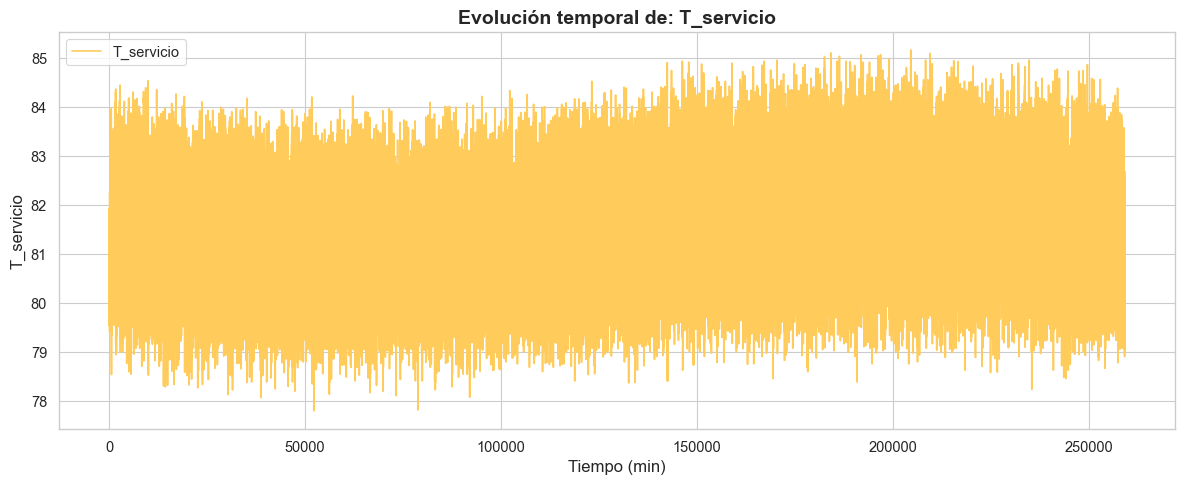

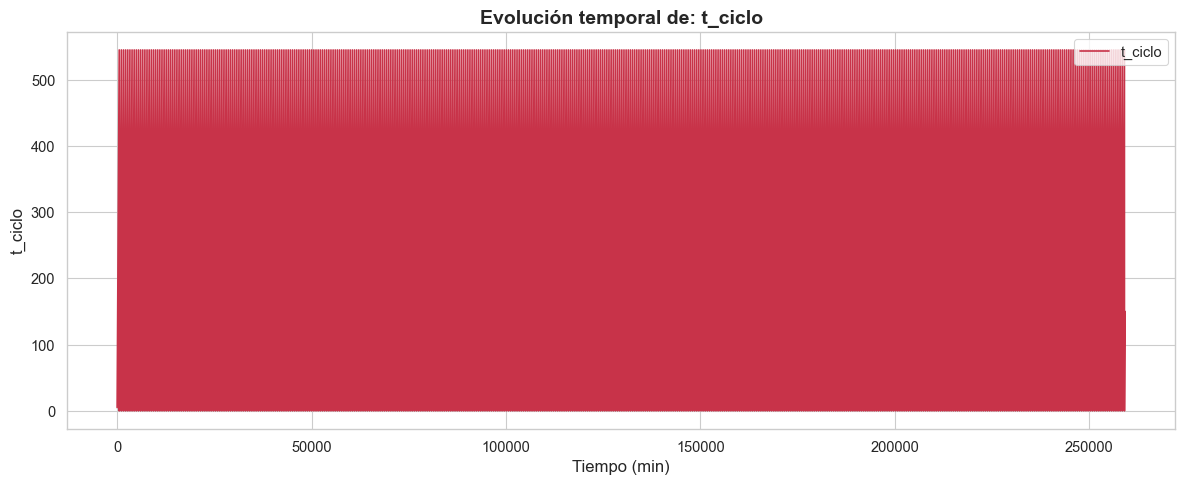

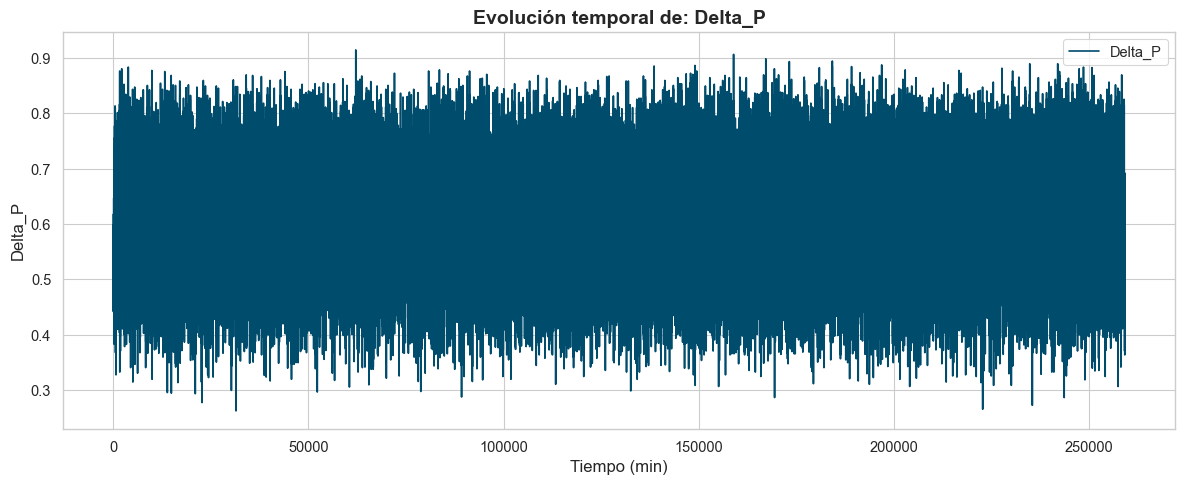

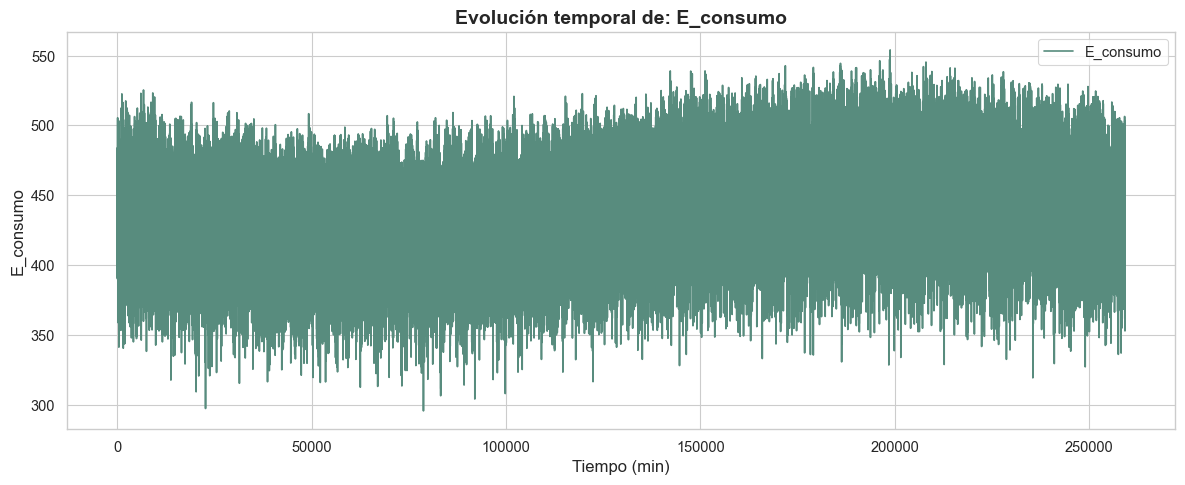

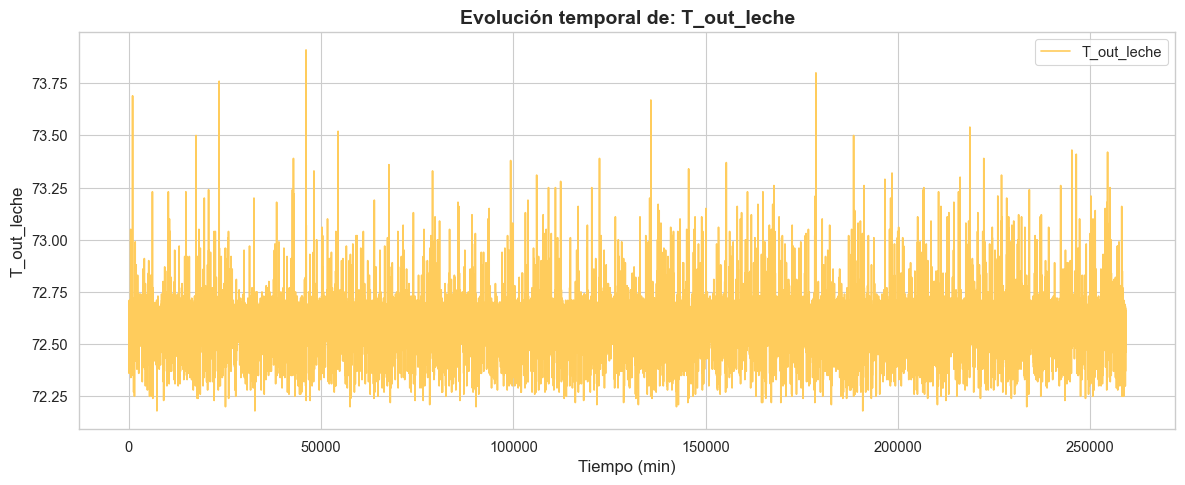

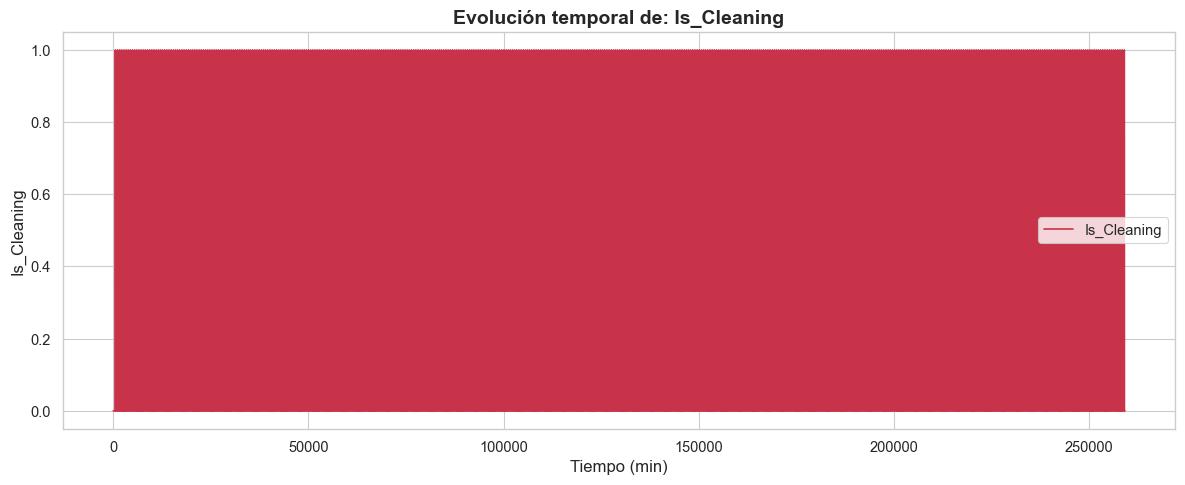

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual (coherente con notebooks 2 y 3)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
COLORS = ["#004c6d", "#588c7e", "#ffcc5c", "#c83349"]
sns.set_palette(sns.color_palette(COLORS))

# Variables a graficar (todas menos la columna de tiempo)
variables = [col for col in df_simulado.columns if col != 'Time_min']

# Generar un gráfico por cada variable
for i, var in enumerate(variables):
    plt.figure(figsize=(12, 5))
    color = COLORS[i % len(COLORS)]
    sns.lineplot(x=df_simulado['Time_min'], y=df_simulado[var], label=var, color=color)
    plt.title(f'Evolución temporal de: {var}', fontsize=14, fontweight='bold')
    plt.xlabel('Tiempo (min)', fontsize=12)
    plt.ylabel(var, fontsize=12)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

---

**Siguiente paso:** Con el dataset sintetico generado y almacenado en `data/raw/pasteurizacion_dataset_simulado.csv`, procedemos al **Analisis Exploratorio de Datos (EDA)** en el Notebook 2.

En el EDA se examinaran distribuciones, correlaciones, dinamica del fouling, estructura temporal y relacion entre `F_flow`, `T_servicio`, `E_consumo` y `T_out_leche`. Esto servira para fundamentar las decisiones de preprocesado y la arquitectura del modelo predictivo que despues alimentara al Algoritmo Genetico.

En esta version no se genera una tabla operaria de setpoints. La temperatura de servicio vuelve a estar determinada por una logica PID/supervisor, de forma que el dataset representa datos de planta seguros y no combinaciones artificiales no factibles.

In [11]:
T_out = df_simulado["T_out_leche"]
print(T_out.describe())

count    51840.000000
mean        72.596900
std          0.080419
min         72.180000
25%         72.560000
50%         72.600000
75%         72.630000
max         73.910000
Name: T_out_leche, dtype: float64


In [12]:
print("Distribución de T_out_leche:")
print(df_simulado["T_out_leche"].describe().round(3))

n = len(df_simulado)

p_no_factibles = (df_simulado["T_out_leche"] < 72.3).mean()
p_marginales = (
    (df_simulado["T_out_leche"] >= 72.3)
    & (df_simulado["T_out_leche"] < 72.8)
).mean()
p_seguras = (df_simulado["T_out_leche"] >= 72.8).mean()

print(f"No factibles (<72.3): {100*p_no_factibles:.2f}%")
print(f"Marginales [72.3, 72.8): {100*p_marginales:.2f}%")
print(f"Seguras (>=72.8): {100*p_seguras:.2f}%")

print("\nRangos operativos:")
print(df_simulado[[
    "F_flow",
    "T_servicio",
    "t_ciclo",
    "Delta_P",
    "E_consumo",
    "T_out_leche"
]].describe().round(3))

Distribución de T_out_leche:
count    51840.000
mean        72.597
std          0.080
min         72.180
25%         72.560
50%         72.600
75%         72.630
max         73.910
Name: T_out_leche, dtype: float64
No factibles (<72.3): 0.42%
Marginales [72.3, 72.8): 98.37%
Seguras (>=72.8): 1.21%

Rangos operativos:
          F_flow  T_servicio    t_ciclo    Delta_P  E_consumo  T_out_leche
count  51840.000   51840.000  51840.000  51840.000  51840.000    51840.000
mean    4917.889      81.539    272.387      0.603    435.170       72.597
std      333.198       1.182    158.793      0.099     36.335        0.080
min     3520.840      77.800      0.000      0.263    295.880       72.180
25%     4696.550      80.680    135.000      0.533    410.240       72.560
50%     4942.765      81.530    270.000      0.601    433.635       72.600
75%     5174.572      82.370    410.000      0.671    459.100       72.630
max     5500.000      85.170    545.000      0.914    554.020       73.910
